# IAT 461 / 882 — Assignment 2: Modeling Phigma User Behavior

**Name:** `Arriyan Ali`  
**SFU ID:** `301473637`  
**Date:** `7/5/2026`

---

> Before you start: read the full assignment README on Canvas.  
> Run cells top-to-bottom. Do **not** skip cells — later cells depend on earlier ones.  
> Every cell marked `# YOUR CODE HERE` must be completed.  
> Every cell marked `**✏️ Your interpretation:**` must be filled in with your own words.


## Setup

Run this cell first. It imports all libraries used throughout the notebook.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import scipy.stats as stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)
from sklearn.preprocessing import StandardScaler

# Plot style
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})
ACCENT = '#e8925a'   # course accent colour

print("Libraries loaded.")


Libraries loaded.


---

## Part A — Linear Regression: Did the AI Assistant Change User Behavior?

**Dataset:** `phigma_ab_study.csv`  
**Research question:** Does access to Phigma's AI design assistant increase whiteboard session duration among free-tier users?

This is a **between-subjects experiment**. Users were randomly assigned to treatment (AI access) or control (no AI). We use OLS regression to estimate the effect of the treatment while controlling for other variables.

> **No train/test split in this part.** We are doing statistical inference — explaining the outcome — not predicting future users.


### Load the data

In [ ]:
df_ab = pd.read_csv('phigma_ab_study.csv')

print(f"Shape: {df_ab.shape}")
print(f"\nColumn types:\n{df_ab.dtypes}")
print(f"\nFirst 3 rows:")
df_ab.head(3)


Shape: (2000, 12)

Column types:
user_id                                 object
ab_group                                object
device_type                             object
account_age_days                         int64
prior_whiteboard_sessions                int64
plan_region                             object
num_collaborators                        int64
feature_tour_completed                   int64
templates_used                           int64
ai_suggestions_used                      int64
whiteboard_actions_per_session           int64
avg_whiteboard_session_duration_min    float64
dtype: object

First 3 rows:


,user_id,ab_group,device_type,account_age_days,prior_whiteboard_sessions,plan_region,num_collaborators,feature_tour_completed,templates_used,ai_suggestions_used,whiteboard_actions_per_session,avg_whiteboard_session_duration_min
0,U76582,control,tablet,478,4,EU,3,1,0,0,67,29.70
1,U49158,control,desktop,633,9,APAC,1,0,1,0,72,32.32
2,U82668,control,desktop,159,10,NaN,5,1,1,0,38,17.91


In [ ]:
# Summary statistics
df_ab.describe(include='all').round(2)


,user_id,ab_group,device_type,account_age_days,prior_whiteboard_sessions,plan_region,num_collaborators,feature_tour_completed,templates_used,ai_suggestions_used,whiteboard_actions_per_session,avg_whiteboard_session_duration_min
count,2000,2000,2000,2000.00,2000.00,1323,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00
unique,1978,2,3,NaN,NaN,3,NaN,NaN,NaN,NaN,NaN,NaN
top,U79488,control,desktop,NaN,NaN,EU,NaN,NaN,NaN,NaN,NaN,NaN
freq,2,1011,1211,NaN,NaN,593,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,356.43,4.51,NaN,2.16,0.58,2.79,3.63,84.55,39.53
std,NaN,NaN,NaN,207.82,3.33,NaN,2.37,0.49,2.33,4.87,44.35,20.18
min,NaN,NaN,NaN,7.00,0.00,NaN,0.00,0.00,0.00,0.00,8.00,6.27
25%,NaN,NaN,NaN,178.00,2.00,NaN,0.00,0.00,1.00,0.00,54.00,25.51
50%,NaN,NaN,NaN,352.50,4.00,NaN,1.00,1.00,2.00,0.00,76.00,35.40
75%,NaN,NaN,NaN,533.25,6.00,NaN,3.00,1.00,4.00,7.00,106.00,48.93


In [ ]:
df_ab = pd.read_csv('phigma_ab_study.csv', keep_default_na=False)

This ensures that the NA values are read correct

In [ ]:
# Missing values
df_ab.isnull().sum()


,0
user_id,0
ab_group,0
device_type,0
account_age_days,0
prior_whiteboard_sessions,0
plan_region,0
num_collaborators,0
feature_tour_completed,0
templates_used,0
ai_suggestions_used,0


### A1 — Exploratory Data Analysis

#### A1.1 — Outcome distribution


In [ ]:
BEGIN
    Load target outcome variable

    // 1. Normality & Transformation Visualizations
    Initialize three-panel visual layout

    Draw histogram of raw outcome distribution
    Transform outcome variable using natural logarithm
    Draw histogram of log-transformed outcome distribution
    Draw Q-Q plot comparing log-transformed distribution to a normal distribution

    Render visualizations

    // 2. Statistical Diagnostics
    Compute and output skewness for both raw and log-transformed distributions
END

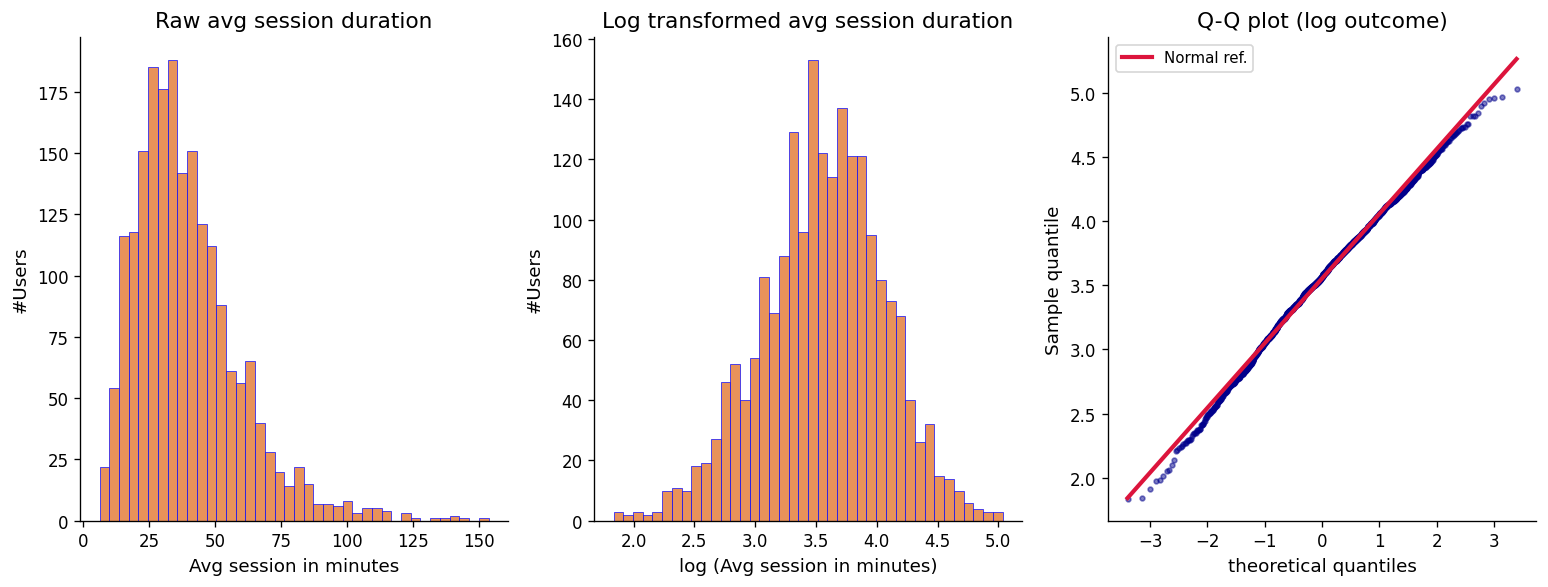

Skewness - raw outcome : 1.3768
Skewness - log outcome : -0.2135
{'(R² of Q-Q fit)        : 0.9969'}


In [ ]:
y_raw = df_ab['avg_whiteboard_session_duration_min']
y_log = np.log(y_raw)
fig,axes = plt.subplots(1, 3, figsize=(13, 5))
# raw data frane


axes[0].hist(y_raw, bins=40, color=ACCENT, edgecolor= 'blue', linewidth=0.4)
axes[0].set_title("Raw avg session duration")
axes[0].set_xlabel("Avg session in minutes")
axes[0].set_ylabel("#Users")

#log transformed
axes[1].hist(y_log, bins=40, color=ACCENT, edgecolor= 'blue', linewidth=0.4)
axes[1].set_title("Log transformed avg session duration")
axes[1].set_xlabel("log (Avg session in minutes)")
axes[1].set_ylabel("#Users")

#Q-Q plot of log outcome
# osm = order statistic medians
# osr = ordered sample ranks

# slope and intercept = reference line
# r = correalation coefficient between osm and osr
(osm, osr), (slope, intercept, r) = stats.probplot(y_log, dist='norm')
axes[2].scatter(osm, osr, color='darkblue', s=8, alpha=0.5)
axes[2].plot(osm, slope*np.array(osm) + intercept, color="crimson", lw=2.5, label='Normal ref.')
axes[2].set_title("Q-Q plot (log outcome)")
axes[2].set_xlabel("theoretical quantiles")
axes[2].set_ylabel("Sample quantile")
axes[2].legend(fontsize=9)

plt.tight_layout()
plt.show()

skew_raw = float(y_raw.skew())
skew_log = float(y_log.skew())
print(f"Skewness - raw outcome : {skew_raw:.4f}")
print(f"Skewness - log outcome : {skew_log:.4f}")
print({f"(R² of Q-Q fit)        : {r**2:.4f}"})

**✏️ Your interpretation (A1.1):**

<br>

**Is the log-transformed outcome more normally distributed?**

The raw histogram is strongly right-skewed, with a sharp spike up from 0 and a peak at around 35 minutes and a tail stretching into the left side.

The log histogram is comparitavely more symmetrical, tapering relatively evenly on both sides and cetering the bulk.

**How does the Q-Q plot support your conclusion?**

In the middle range, the points track the blue points align with the red normal reference line quite closely - which indicates that most of the data lines up to how we'd expect if the data were truly normally distributed.

**Will you use the raw or log outcome in your model?**

I will use the log outcome, I say this due to whats shown in both the histogram and Q-Q plot. The raw outcome is heavily skewed to the right which would be a poor fit for a model that assumes normal distribution (OLS regression). The log transform drastically improves the symetry and balance of the two tail ends. The Q-Q plot shows that most of the data aligns with the normal reference line, there are some remaining tail deviation but it is not severe.



#### A1.2 — Examine the confounders

In [ ]:
// Define the analytical pipeline
BEGIN
    Load AB testing dataset

    // 1. Visual Exploratory Data Analysis
    Initialize side-by-side visualization layouts

    Draw boxplot comparison of AI suggestion usage across experimental groups
    Draw scatter plot comparing whiteboard activity density against session durations

    Optimize layout and display visualizations

    // 2. Statistical Analysis
    Calculate and print the correlation between whiteboard activity and session duration
    Calculate and print descriptive statistics for AI suggestion usage grouped by treatment group
END

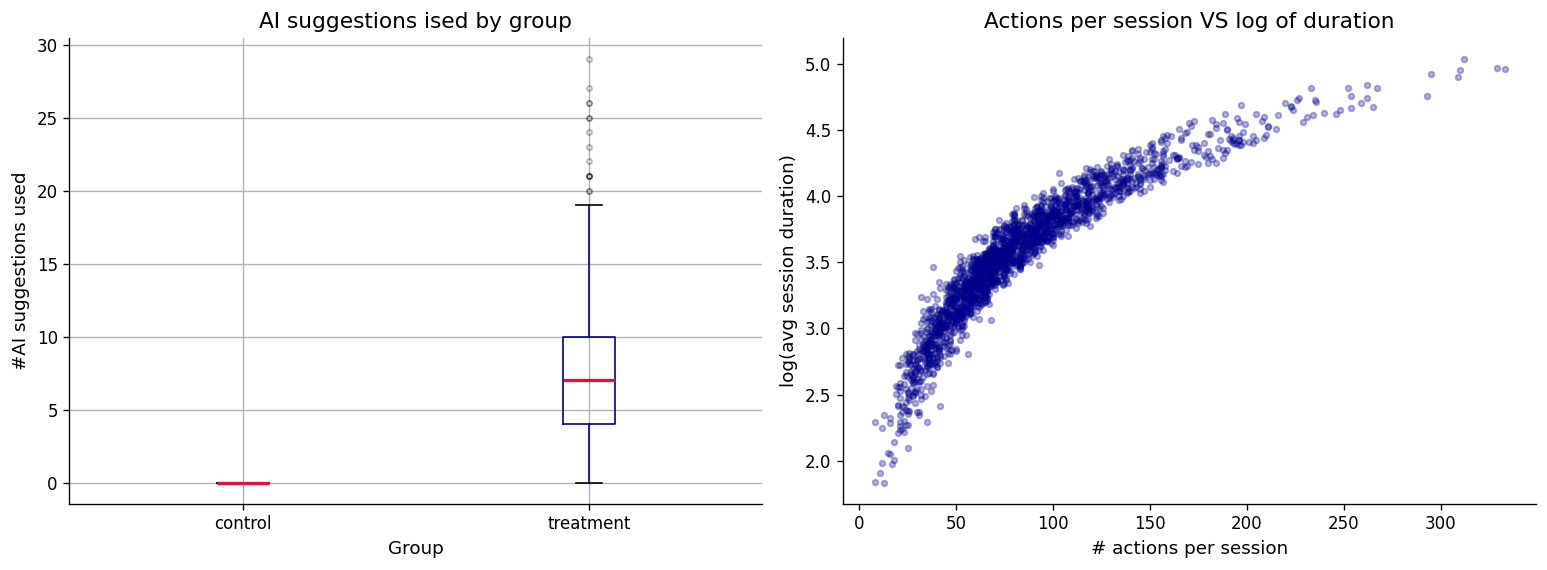

Pearson r (whiteboard_actions_per_session vs log_duration): 0.9136

Descriptive stats for ai_suggestions_used by group:
            count  mean   std  min  25%  50%   75%   max
ab_group                                                
control    1011.0  0.00  0.00  0.0  0.0  0.0   0.0   0.0
treatment   989.0  7.33  4.55  0.0  4.0  7.0  10.0  29.0


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13,5))

#left boxplot of ai suggestions
df_ab.boxplot(
    column='ai_suggestions_used', by='ab_group', ax=axes[0],
    boxprops=dict(color='darkblue'), medianprops=dict (color='crimson', lw=2),
    whiskerprops=dict(color='darkblue'), capprops=dict(color='black'),
    flierprops=dict(marker='o', color='blue', alpha=0.3, markersize=3)
)
axes[0].set_xlabel('Group')
axes[0].set_title("AI suggestions used by exp group")
axes[0].set_ylabel('#AI suggestions used')
plt.sca(axes [0])
plt.title("AI suggestions ised by group")
plt.suptitle('')

#right side scatter plot of white board actions per session vs log(duration)
log_dur= np.log(df_ab ['avg_whiteboard_session_duration_min'])
axes[1].scatter(df_ab['whiteboard_actions_per_session'], log_dur, color='darkblue',
                alpha=0.3, s=12
)

axes[1].set_title('Actions per session VS log of duration')
axes[1].set_xlabel('# actions per session')
axes[1].set_ylabel('log(avg session duration)')

plt.tight_layout()
plt.show()

corr_actions = df_ab['whiteboard_actions_per_session'].corr(log_dur)
print(f"Pearson r (whiteboard_actions_per_session vs log_duration): {corr_actions:.4f}")

print("\nDescriptive stats for ai_suggestions_used by group:")
print(df_ab.groupby('ab_group')['ai_suggestions_used'].describe().round(2))



**✏️ Your interpretation (A1.2):**


**What do you notice about `ai_suggestions_used` across the two groups?**
Control has no variance, every user has no AI suggestions used. This would make sense since the AI suggestions would only be available to the treatment group.
The treatment group shows variation, with around 7 to 8 suggestions used on average, with an overall range of 0 to 29. There is also a cluster of outliers at the top end.


**What does the correlation between `whiteboard_actions_per_session` and the outcome suggest?**

Pearson r-0.91 between the actions per session and log duration is a very high positive linear correalation. The scattor plot affirms this , it shows a compact pattern that is increasing.This 0.91 correalation is very high, meaning that the two variables are moving somewhat together so they should not be treated as seperate or independent predictors.


**Why should neither be included in your model?**

ai_suggestions_used is a consequence of the treatment, not a predictor in itself. The variable is there because of the treatment group. The suggestions used aren't an independent factor thats influencing the outcome, it is one of the steps within the process that contributes. So including this in the model would give a harder to interpret result, rather than the total effect of treatment on duration.

As for whiteboard_actions_per_session, it is strongly related to the actual log_duration outcome itself. This might mean its showcasing the same underlying thing (like engagement). Including both would imply they are two, distinct predictors - which they are not since theyre are so heavily correalated. Since they are so correalated, adding whiteboard_actions_pers_session barely adds any new information since log_duration is already there.



#### A1.3 — Predictor distributions and relationships with outcome

**** account_age_days ****
**** prior_whiteboard_sessions ****
**** num_collaborators ****


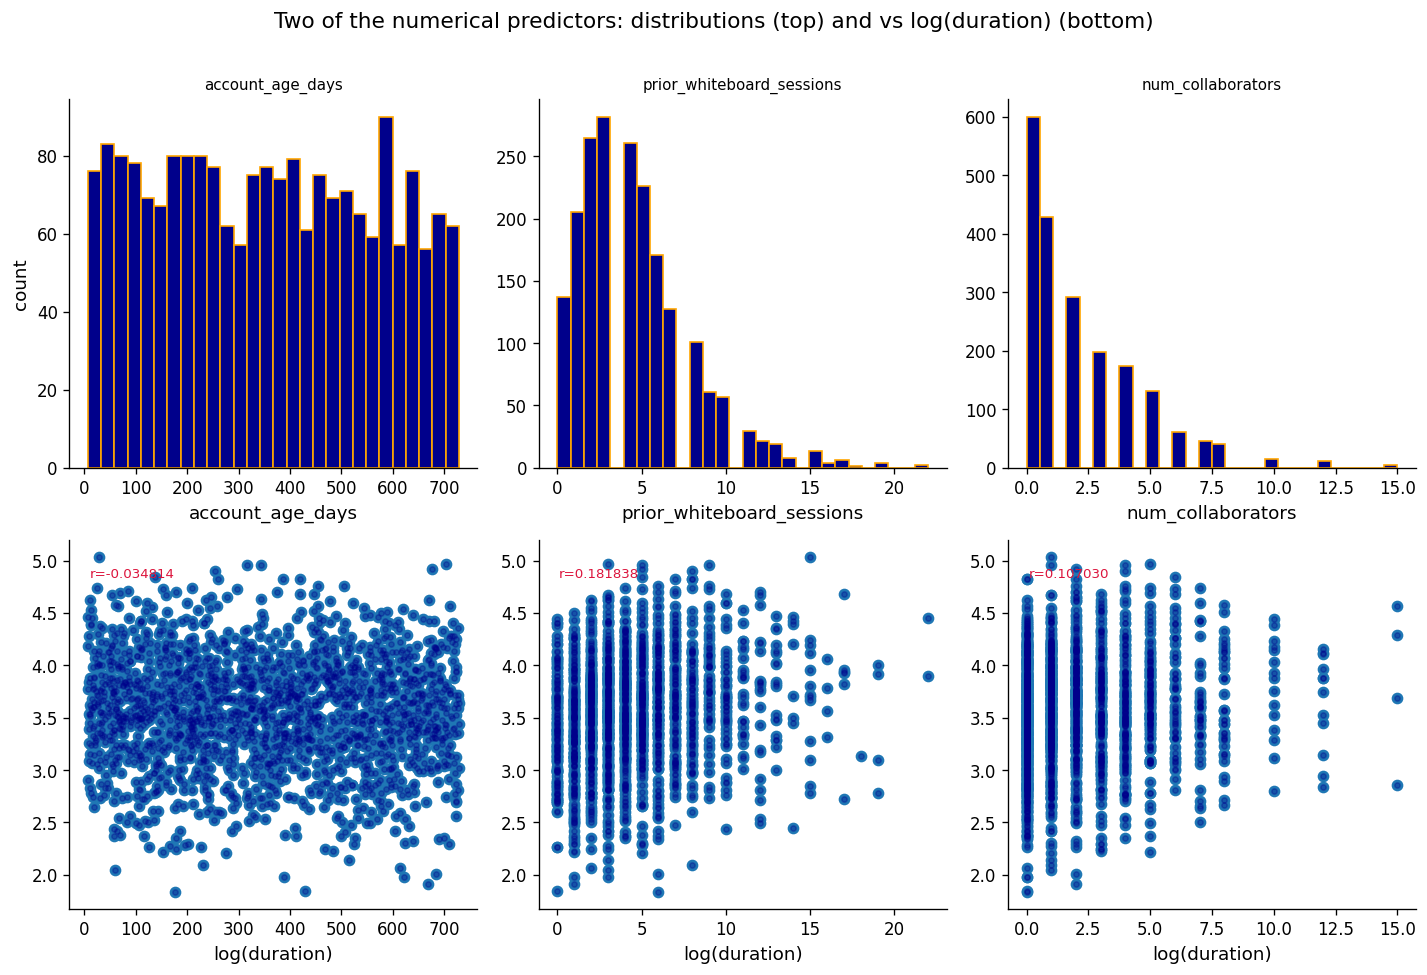

In [ ]:
from matplotlib.figure import figaspect
num_predictors = [
    'account_age_days',
    'prior_whiteboard_sessions',
    'num_collaborators'
]

n = len(num_predictors)

fig, axes = plt.subplots(2, n, figsize=(4*n, 8))
fig.suptitle('Two of the numerical predictors: distributions (top) and vs log(duration) (bottom)',
             fontsize=13, y=1.01)

for j, col in enumerate(num_predictors):

  print("****", col, "****")
  # top row: histogram
  axes[0, j].hist(df_ab[col], bins=28, color='darkblue', edgecolor='orange', lw=0.4)
  axes[0, j].set_title(col, fontsize=9)
  axes[0, j].set_xlabel(col)
  axes[0, j].set_ylabel('count' if j==0 else '')

  # bottom row: scatterplot
  r = df_ab[col].corr(log_dur)
  axes[1,j].scatter(df_ab[col], log_dur)
  axes[1, j].scatter(df_ab[col],log_dur, color='darkblue', alpha=0.3, s=10)
  axes[1, j].set_xlabel('log(duration)')
  axes[1, j].annotate(f'r={r:2f}', xy=(0.05, 0.9),
                      xycoords='axes fraction', fontsize=8, color='crimson')

plt.tight_layout()
plt.show()

In [ ]:
BEGIN
    Define list of numerical predictor variables
    Compute log-transformed outcome variable

    Initialize visual grid layout (2 rows by N columns, where N is the number of predictors)

    FOR each predictor variable:
        // Top row: Univariate Analysis
        Draw histogram to show distribution of the predictor

        // Bottom row: Bivariate Analysis
        Draw scatter plot comparing predictor against log-transformed outcome
        Calculate correlation coefficient between predictor and log-transformed outcome
        Annotate plot with correlation coefficient
    END FOR

    Add global title and render layout
END

In [ ]:
BEGIN
    Define list of categorical predictor variables
    Initialize visual grid layout (1 row by N columns, where N is the number of categories)

    FOR each categorical variable:
        Retrieve unique category levels

        Group log-transformed outcome values by category levels

        Draw boxplots of log-transformed outcome grouped by category level
        Rotate category axis labels for readability

        Label axis and set titles
    END FOR

    Render layout
END

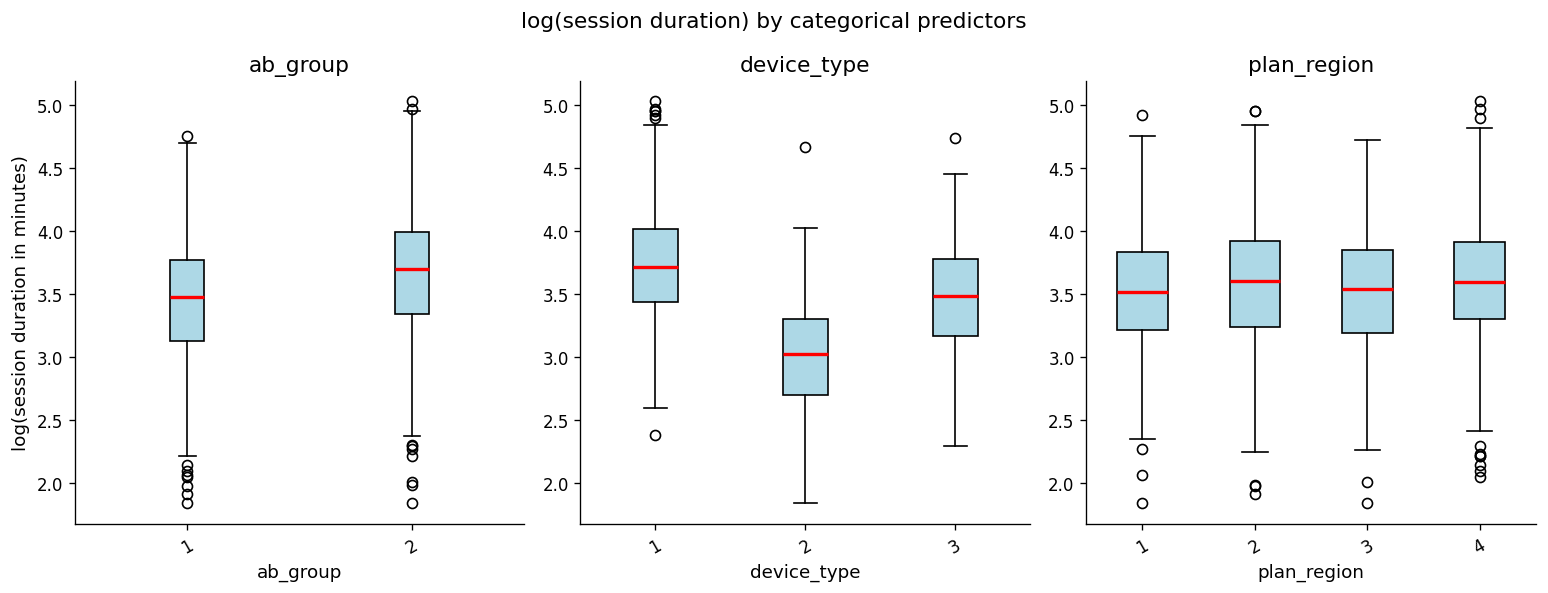

In [ ]:
cat_predictors = ['ab_group', 'device_type', 'plan_region']

log_dur = np.log(df_ab['avg_whiteboard_session_duration_min'])

fig, axes = plt.subplots(1, len(cat_predictors), figsize=(13,5))

fig.suptitle('log(session duration) by categorical predictors', fontsize=13)

for j, col in enumerate(cat_predictors):
  levels = sorted(df_ab[col].unique())
  grouped = [log_dur[df_ab[col] == lvl].values for lvl in levels]
  axes[j].boxplot(grouped, label=levels, patch_artist=True,
                  boxprops=dict(facecolor="lightblue"), medianprops=dict(color='red', lw=2))
  axes[j].set_title(col)
  axes[j].set_xlabel(col)
  axes[j].set_ylabel('log(session duration in minutes)' if j == 0 else '')
  axes[j].tick_params(axis='x', rotation = 30)

plt.tight_layout()
plt.show()

**✏️ Your interpretation (A1.3):**


**3–5 sentences summarizing your EDA.**
The measurable/numerical predictors show weaker linear correalations with log(duration). The categorical predictors show more of a noticable group difference, especially by device_type.



**Which predictors look most promising?**
device_type shows an obvious median gap between the groups. ab_group shows visible distinction between the treatment and control groups. For the numerical predictors prior_whiteboard_sessions is the strongest at r=0.18, although its still pretty weak.


**Are any right-skewed and worth log-transforming before use as predictors?**
prior_whiteboard_sessions and num_collaborators are both shown as right-skewed and worth log transforming



**Which two features are you excluding and why?**
I would exclude account_age_dats and plan_region since both show pretty flat relationships with log(duration). They would help figure out or predict the differences in session duration


### A2 — Feature Engineering

Prepare your feature matrix for OLS. Exclude the two problematic variables identified in A1.


In [ ]:
BEGIN
    Load baseline dataset

    // 1. Encode Categorical Variables
    Convert experimental group ('ab_group') into a binary integer indicator
    Generate dummy indicators (one-hot encoding) for device types, omitting the first category
    Generate dummy indicators (one-hot encoding) for regions, omitting the first category

    // 2. Perform Optional Transformations
    Log-transform right-skewed numerical predictors using log(x + 1) to avoid zero values

    // 3. Assemble Modeling Dataset
    Merge numerical characteristics, binary groups, and dummy indicators into matrix X
    Set target vector y as the log-transformed outcome variable

    // 4. Quality Control
    Verify that there are no missing (null) values in feature matrix X
    Inspect matrix dimensions and print a preview of the processed data
END

In [ ]:
df_ab['ab_group_enc'] = (df_ab ['ab_group']=='treatment').astype(int)
device_dummies = pd.get_dummies (df_ab['device_type'], prefix='device', drop_first=True).astype(int)
region_dummies = pd.get_dummies (df_ab['plan_region'], prefix='region', drop_first=True).astype(int)

log_account_age = np.log1p (df_ab['account_age_days'])
log_prior_whiteboard_sessions = np.log1p(df_ab['prior_whiteboard_sessions'])
log_num_collaborators = np.log1p (df_ab ['num_collaborators'])

X = pd.concat([
  df_ab['ab_group_enc'].rename('ab_group'),
  log_account_age.rename('log_account_age_days'),
  log_prior_whiteboard_sessions.rename('log_whiteboard_sessions'),
  log_num_collaborators.rename('log_num_collaborators'),
  device_dummies,
  region_dummies
], axis=1)
y= np. log(df_ab['avg_whiteboard_session_duration_min'])

assert X.isnull().sum().sum() == 0
print(f"Feature matrix shape: {X.shape}")
print(f"Missing values in X: {X.isnull().sum().sum()}")
print(f"\nFeature columns:\n{X.columns.tolist()}")
X.head(3)

Feature matrix shape: (2000, 9)
Missing values in X: 0

Feature columns:
['ab_group', 'log_account_age_days', 'log_whiteboard_sessions', 'log_num_collaborators', 'device_mobile', 'device_tablet', 'region_EU', 'region_LATAM', 'region_NA']


,ab_group,log_account_age_days,log_whiteboard_sessions,log_num_collaborators,device_mobile,device_tablet,region_EU,region_LATAM,region_NA
0,0,6.171701,1.609438,1.386294,0,1,1,0,0
1,0,6.452049,2.302585,0.693147,0,0,0,0,0
2,0,5.075174,2.397895,1.791759,0,0,0,0,1


**✏️ Your interpretation (A2):**

**List your final features. For each one, write one sentence justifying its inclusion and any transformation applied:**

---

<br>

**ab_group**<br>
Treatment variable itself, so its neccesary to answer the main question of whether the AI assistant access changes session duration. It's already 0/1 so it doesnt need any transformations

**log_account_age_days**<br>
Used as baseline control for how long someones had an account. It would be log transformed to handel its large range

**log_whiteboard_sessions**<br>
Shows how much experience a user alread had with the profuct prior to the experience. It would need to be log transformed since its raw values are right skewed

**log_num_collaborators**<br>
This would be a rough stand in for the team size or account complexity. It would also need to be transformed to account for outliers.

**device_mobile, device_tablet**<br>
Kept because the EDA showed that session duration clearly differs by device

**region_EU, region_LATAM, region_NA**<br>
Included as some geographic control


In [ ]:
# transforming final features that need to be transformed

df_ab['log_account_age_days']=np.log1p(df_ab['account_age_days'])
df_ab['log_whiteboard_sessions']=np.log1p(df_ab['prior_whiteboard_sessions'])
df_ab['log_num_collaborators']=np.log1p(df_ab['num_collaborators'])


### A3 — OLS Regression


In [ ]:
# YOUR CODE HERE
# Add a constant for the intercept, then fit OLS
X_const = sm.add_constant(X)
model_ols = sm.OLS(y, X_const).fit(cov_type='HC3')
print(model_ols.summary())


                                     OLS Regression Results                                    
Dep. Variable:     avg_whiteboard_session_duration_min   R-squared:                       0.358
Model:                                             OLS   Adj. R-squared:                  0.355
Method:                                  Least Squares   F-statistic:                     111.6
Date:                                 Mon, 06 Jul 2026   Prob (F-statistic):          1.76e-169
Time:                                         23:10:39   Log-Likelihood:                -1028.8
No. Observations:                                 2000   AIC:                             2078.
Df Residuals:                                     1990   BIC:                             2134.
Df Model:                                            9                                         
Covariance Type:                                   HC3                                         
                              coef    st

#### A3.1 — Interpret the model

In [ ]:
BEGIN
    Input trained OLS regression model
    Input experimental dataframe

    // 1. Evaluate Model Fit
    Display model's R-squared value to assess variance explained

    // 2. Analyze Treatment Effect
    Extract coefficient and significance (p-value) for the A/B testing variable
    Convert the log-space treatment coefficient back to its scale in physical time (minutes)
    Display treatment effect size and statistical significance

    // 3. Extract Significant Predictors
    Filter all model coefficients where p-value < 0.05
    FOR each significant variable:
        Display variable name, its directional coefficient, and its p-value
    END FOR
END

In [ ]:
print(f"R²         = {model_ols.rsquared:.4f}")
print(f"Adj. R²    = {model_ols.rsquared_adj:.4f}")

ab_coef = model_ols.params['ab_group']
ab_pval = model_ols.pvalues['ab_group']

# y = log(duration)

ab_pct_change = (np.exp(ab_coef) - 1)

control_mean = df_ab.loc[df_ab['ab_group'] == 'control', 'avg_whiteboard_session_duration_min'].min()

ab_mins_effect = control_mean * (np.exp(ab_coef) - 1)

print(f"ab_group coefficient  : {ab_coef:.4f}")
print(f"p-value               : {ab_pval:.4f}")
print(f"Back=transformed      : {ab_pct_change:1f}% relative to control mean")
print(f"                      : ~= {ab_mins_effect:.1f} min above control mean ({control_mean:.1f} min)")

# significant predictors with p<0.05

sig = model_ols.pvalues[model_ols.pvalues < 0.05].sort_values()
print('significant predictors are: ')
for var, pv in sig.items():
  coef=model_ols.params[var]
  print(f". {var:<35s}.  coef {coef:.4f}.  p={pv:.4f}")

R²         = 0.3576
Adj. R²    = 0.3547
ab_group coefficient  : 0.2170
p-value               : 0.0000
Back=transformed      : 0.242299% relative to control mean
                      : ~= 1.5 min above control mean (6.3 min)
significant predictors are: 
. const                              .  coef 3.3722.  p=0.0000
. device_mobile                      .  coef -0.7257.  p=0.0000
. device_tablet                      .  coef -0.2579.  p=0.0000
. ab_group                           .  coef 0.2170.  p=0.0000
. log_whiteboard_sessions            .  coef 0.1407.  p=0.0000
. log_num_collaborators              .  coef 0.0861.  p=0.0000
. region_NA                          .  coef 0.0826.  p=0.0003
. region_EU                          .  coef 0.0768.  p=0.0017


**✏️ Results paragraph (A3):**

*Write a results paragraph as if reporting in a research paper. Include:*
- *The treatment effect estimate and its significance*
- *R^2 and what it tells you about model fit*
- *At least two other notable predictors and their direction*
- *Whether the AI assistant's effect is practically meaningful (not just statistically significant)*



---

People who had access to the AI assistant spent noticable more time in their sessions than those who didnt, about 24% more or roughly 1.5 extra minutes (on top of the control ggroups average of 6.3 minutes). This result is statistically significant, meaning it's very unlikely for it to be due to chance. The model explains a moderate amount od wht session times vary (R² = 0.3576), so other factos I didnt measure are likely playing a role here too. Device type made the biggest difference overall, mobile users had much shorter sessions than desktop users, and tablet users were somewhat shorter as well. How much people used the Phigma before the experiment also mattered. People who used it more in the past + who had more collaborators on their account, tended to have longer sessions. The AI assisteant;s effect is practically meaningful since a 24% increase in session length is a substantial difference in behavior, making it a major factor in the whole model (alongside device type).

#### A3.2 — Regression diagnostics

In [ ]:
BEGIN
    Extract predictions and error terms (residuals) from regression model
    Initialize a side-by-side diagnostic visualization layout

    // Check for uniform variance (homoscedasticity)
    Draw scatter plot of prediction values vs residuals
    Overlay a horizontal zero-error baseline reference line

    // Check for normality of errors
    Draw a Q-Q plot of residuals against a normal theoretical distribution

    Render diagnostic plots
END

Text(0.5, 1.0, 'Q-Q Plot of Residuals')

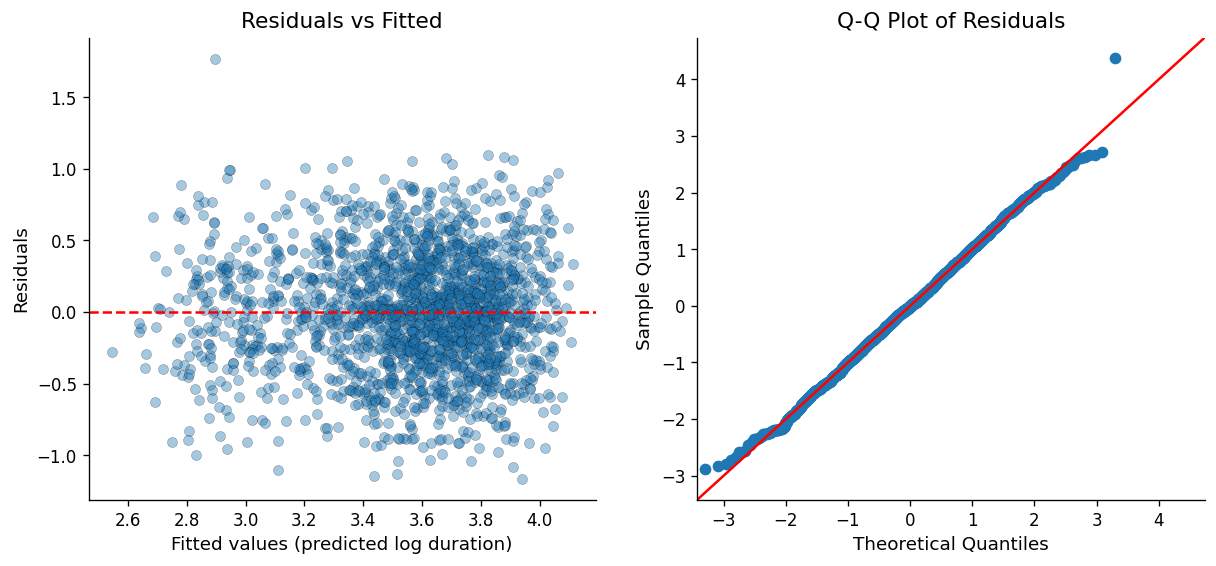

In [ ]:
# Extracting predictions and error terms from regression model
fitted_values = model_ols.fittedvalues
residuals = model_ols.resid

# Initializing side-by-side visualization layout
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Checking homoscedasticity and Plot #1:
axes[0].scatter(fitted_values, residuals, alpha=0.4, edgecolor='k', linewidth=0.3)
axes[0].axhline(y=0, color='red', linestyle='--', linewidth=1.5)
axes[0].set_xlabel('Fitted values (predicted log duration)')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Residuals vs Fitted')

# Checking normality and Plot#2
sm.qqplot(residuals, line='45', fit=True, ax=axes[1])
axes[1].set_title('Q-Q Plot of Residuals')

# Rendering plots

**✏️ Your interpretation (A3.2):**

**Do the residuals look randomly scattered around zero?**<br>
Yes, for the most part. The point showcase a generally even cloud from below and above the red 0 line in. There isnt any obvious funnel or cone shape so it is showing homoscedasticity (it was mentioned in the pseudocode to check for this).

**Does the Q-Q plot suggest normally distributed errors?**<br>
Again yes mostly, although not perfect. The middle area points hug the red line which is good but both tails lift off a bit. The lower tail is slightly off the line and the upper tail pulls off a bit too.

**Note any patterns that concern you.** <br>
The most obvious thing I notice is the outlier on both plots that is sitting way above. This point looks extreme compared to the rest of the data. I's assume it could be a data entry error, or just a really special user who loves Phigma. Aside from that, the rest looks good.

### A4 — Exploratory Interaction Analysis

The average treatment effect hides heterogeneity — the AI assistant may help some users more than others.


**✏️ State your hypothesis here (before writing any code):**


**Which interaction are you testing?**<br>
The interaction between ab_group and log_num_collaborators

**Which two variables?**<br>
ab_group (treatment vs control groups) <br>
log_num_collaborators (log transformed number of collaborators on a users account)


**What is your theoretical reason for expecting this interaction?** <br>
When more people are collaboarating on Phigma, things get more complicated. There would be more cordination, back and forth about ideas, and more aspects to keep track of. The AI suggestions would rationally help cut down some of that work or help expedite it. However, if its just one person working alone/only a few people collaborating, then the session might be simpler to begin with (not as much for the AI to actually fix/expedite)


**Which group do you predict will benefit more from the AI assistant?**<br>
I think users with more collaborators will benefit more. I would predict that there will be a much bigger boost in session duration for accounts with more num_collaborators when compared to those with less/none.


In [ ]:
df_ab.columns.tolist()

['user_id',
 'ab_group',
 'device_type',
 'account_age_days',
 'prior_whiteboard_sessions',
 'plan_region',
 'num_collaborators',
 'feature_tour_completed',
 'templates_used',
 'ai_suggestions_used',
 'whiteboard_actions_per_session',
 'avg_whiteboard_session_duration_min',
 'ab_group_enc',
 'log_account_age_days',
 'log_whiteboard_sessions',
 'log_num_collaborators']

In [ ]:
# YOUR CODE HERE
# Step 1: Create the interaction term
# Example: df_ab['ab_x_device_desktop'] = df_ab['ab_group_enc'] * df_ab['device_desktop']
df_ab['ab_x_log_collab'] = df_ab['ab_group_enc'] * df_ab['log_num_collaborators']

# Step 2: Add the interaction term to your feature matrix and refit OLS
X_interact = X_const.copy()
X_interact['ab_x_log_collab'] = df_ab['ab_x_log_collab']

X_interact = pd.concat([X_const, df_ab['ab_x_log_collab']], axis=1)
model_interact = sm.OLS(y, X_interact).fit()
print(model_interact.summary())


                                     OLS Regression Results                                    
Dep. Variable:     avg_whiteboard_session_duration_min   R-squared:                       0.358
Model:                                             OLS   Adj. R-squared:                  0.355
Method:                                  Least Squares   F-statistic:                     110.8
Date:                                 Mon, 06 Jul 2026   Prob (F-statistic):          3.86e-183
Time:                                         23:10:48   Log-Likelihood:                -1028.6
No. Observations:                                 2000   AIC:                             2079.
Df Residuals:                                     1989   BIC:                             2141.
Df Model:                                           10                                         
Covariance Type:                             nonrobust                                         
                              coef    st

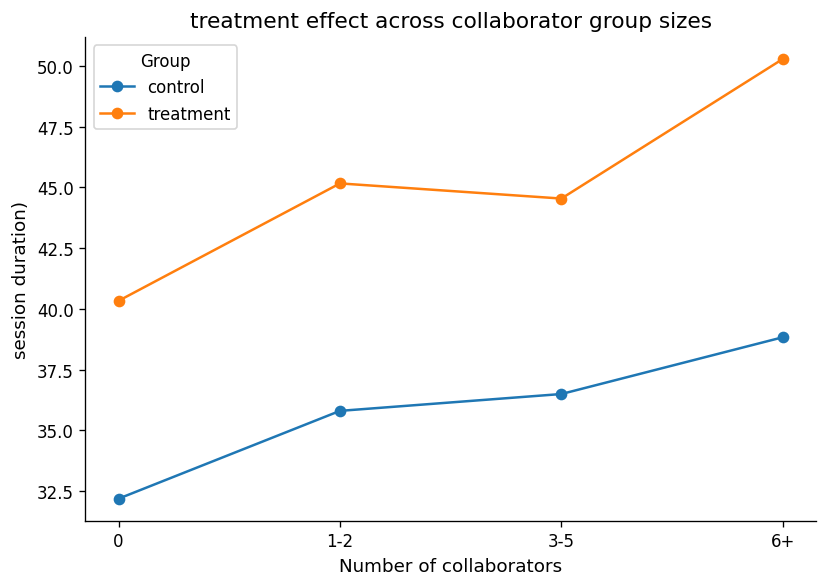

In [ ]:
# YOUR CODE HERE
# Visualize the interaction
# Example: plot mean log(outcome) for treatment vs control, split by the moderating variable
# Use a grouped bar chart or overlapping regression lines

# binning log_num_collaborators for clearer visual
df_ab['collab_bin'] = pd.cut(
    df_ab['num_collaborators'],
    bins=[-1, 0, 2, 5, df_ab['num_collaborators'].max()],
    labels=['0', '1-2', '3-5', '6+']
)

# getting mean for each group against collab_bin combo
grouped = df_ab.groupby(['collab_bin', 'ab_group'])['avg_whiteboard_session_duration_min'].mean().reset_index()

fig, ax = plt.subplots(figsize=(7, 5))

for group_name, group_data in grouped.groupby('ab_group'):
    ax.plot(group_data['collab_bin'], group_data['avg_whiteboard_session_duration_min'], marker='o', label=group_name)

ax.set_xlabel('Number of collaborators')
ax.set_ylabel('session duration)')
ax.set_title('treatment effect across collaborator group sizes')
ax.legend(title='Group')
plt.tight_layout()
plt.show()


**✏️ Your interpretation (A4):**

**Was your hypothesis supported?** <br>
No, the interaction ab_x_log_collab has a coefficient of 0.0161, while the p-valie is 0.523 which is way above the 0.05 cutoff. So it is not significant. This means there is no real evidence of the AI assistant affecting duration based on how many collaborators there are. The chart shows a slight increase in the treatment vs control group of session duration increasing with more collaborators, but this could just be due to noise (it's not a very clear obvious pattern)

**What does the interaction coefficient tell you about which users benefit most from the AI assistant?** <br>
Since the interaction isn't that correalated, the AI assistant's effect looks to be consistent accross different amounts of collaborators


**What does this imply for how Phigma should roll out the feature?**<br>
Since there is no evidence for the AI assistant working better for bigger teams, there wouldnt be any strong evidence to target roll out based on how big a team is. The AI assistant seems to help similar regardless of the number of collaborators

---

## Part B — Logistic Regression: Who Converts?

**Dataset:** `phigma_subscription.csv`  
**Research question:** Which behavioral and demographic factors predict whether a free-tier user subscribes within 30 days?

This dataset requires **feature engineering before modeling**. Several columns arrive as raw datetimes or aggregate counts that need transformation.


In [ ]:
df_sub = pd.read_csv('phigma_subscription.csv')

print(f"Shape: {df_sub.shape}")
print(f"\nColumn types:\n{df_sub.dtypes}")
df_sub.head(3)


Shape: (3000, 15)

Column types:
user_id                         object
signup_date                     object
first_session_date              object
device_type                     object
country_tier                    object
referral_source                 object
num_sessions_30d                 int64
total_time_min_30d               int64
projects_created_30d             int64
exports_30d                      int64
collaborators_invited_30d        int64
support_tickets_30d              int64
used_premium_feature_preview     int64
ai_assistant_sessions_30d        int64
subscribed                       int64
dtype: object


,user_id,signup_date,first_session_date,device_type,country_tier,referral_source,num_sessions_30d,total_time_min_30d,projects_created_30d,exports_30d,collaborators_invited_30d,support_tickets_30d,used_premium_feature_preview,ai_assistant_sessions_30d,subscribed
0,V94735,2024-05-23,2024-05-28,tablet,tier_1,organic,1,96,1,0,0,0,1,6,0
1,V15501,2024-03-05,2024-03-05,tablet,tier_2,social,15,267,8,1,5,0,0,0,0
2,V98542,2024-01-05,2024-01-19,desktop,tier_1,organic,16,263,0,0,3,3,1,4,1


In [ ]:
df_sub.describe(include='all').round(2)


,user_id,signup_date,first_session_date,device_type,country_tier,referral_source,num_sessions_30d,total_time_min_30d,projects_created_30d,exports_30d,collaborators_invited_30d,support_tickets_30d,used_premium_feature_preview,ai_assistant_sessions_30d,subscribed
count,3000,3000,3000,3000,3000,3000,3000.00,3000.00,3000.00,3000.00,3000.00,3000.00,3000.00,3000.00,3000.00
unique,2947,181,200,3,3,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,V43688,2024-06-06,2024-06-27,desktop,tier_1,organic,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,3,33,29,1788,1332,1153,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,9.25,216.17,2.43,2.01,1.86,0.68,0.28,3.64,0.21
std,NaN,NaN,NaN,NaN,NaN,NaN,5.09,139.20,2.30,2.05,2.10,1.07,0.45,2.90,0.41
min,NaN,NaN,NaN,NaN,NaN,NaN,1.00,5.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,NaN,NaN,NaN,NaN,NaN,NaN,6.00,115.75,1.00,0.00,0.00,0.00,0.00,2.00,0.00
50%,NaN,NaN,NaN,NaN,NaN,NaN,8.00,188.50,2.00,2.00,1.00,0.00,0.00,3.00,0.00
75%,NaN,NaN,NaN,NaN,NaN,NaN,12.00,285.00,4.00,3.00,3.00,1.00,1.00,5.00,0.00


### B1 — Feature Engineering

Derive the required features listed in the README before doing any modeling or EDA.


In [ ]:

# 1. Parse dates
df_sub['signup_date'] = pd.to_datetime(df_sub['signup_date'])
df_sub['first_session_date'] = pd.to_datetime(df_sub['first_session_date'])

# 2. days_to_first_session
df_sub['days_to_first_session'] = (
    df_sub['first_session_date'] - df_sub['signup_date']
    ).dt.days

# 3. avg_session_duration_min — handle divide-by-zero explicitly
df_sub['avg_session_duration_min'] = np.where(
    df_sub['num_sessions_30d'] == 0,
    0,
    df_sub['total_time_min_30d'] / df_sub['num_sessions_30d']
)

# 4. is_weekend_signup (1 if Saturday=5 or Sunday=6)
df_sub['is_weekend_signup'] = df_sub['signup_date'].dt.weekday.isin([5, 6]).astype(int)


# 5. One-hot encode device_type (drop first level)
device_dummies2 = pd.get_dummies(df_sub['device_type'], prefix='device', drop_first=True)

# 6. One-hot encode referral_source (drop first level)
referral_dummies = pd.get_dummies(df_sub['referral_source'], prefix='ref', drop_first=True)

# 7. Encode country_tier — ordinal or one-hot (justify below)
df_sub['country_tier_enc'] = df_sub['country_tier'].map(
    {'tier_1':1,'tier_2':2,'tier_3':3}
    )

# 8. Assemble final feature matrix
raw_numeric = [
    'num_sessions_30d', 'total_time_min_30d', 'projects_created_30d',
    'exports_30d', 'collaborators_invited_30d', 'support_tickets_30d',
    'used_premium_feature_preview', 'ai_assistant_sessions_30d'
]

engineered = [
    'days_to_first_session', 'avg_session_duration_min', 'is_weekend_signup',
    'country_tier_enc'
]

X_sub = pd.concat(
    [df_sub[raw_numeric + engineered], device_dummies2, referral_dummies],
    axis = 1
)

y_sub = df_sub['subscribed']

print(f"Any NaN values      : {X_sub.isnull().any().any()}")
print(f"All numeric         : {all(X_sub.dtypes !=object)}")
print(f"Feature matrix shape: {X_sub.shape}")
print(f"\nFeature names     :\n{list(X_sub.columns)}")
X_sub.head(3)


# print(f"Any inf: {np.isinf(X_sub.values).any()}")
print(f"Any NaN: {X_sub.isnull().any().any()}")
print(f"Feature matrix shape: {X_sub.shape}")
X_sub.head(3)




Any NaN values      : False
All numeric         : True
Feature matrix shape: (3000, 17)

Feature names     :
['num_sessions_30d', 'total_time_min_30d', 'projects_created_30d', 'exports_30d', 'collaborators_invited_30d', 'support_tickets_30d', 'used_premium_feature_preview', 'ai_assistant_sessions_30d', 'days_to_first_session', 'avg_session_duration_min', 'is_weekend_signup', 'country_tier_enc', 'device_mobile', 'device_tablet', 'ref_paid_ad', 'ref_referral', 'ref_social']
Any NaN: False
Feature matrix shape: (3000, 17)


,num_sessions_30d,total_time_min_30d,projects_created_30d,exports_30d,collaborators_invited_30d,support_tickets_30d,used_premium_feature_preview,ai_assistant_sessions_30d,days_to_first_session,avg_session_duration_min,is_weekend_signup,country_tier_enc,device_mobile,device_tablet,ref_paid_ad,ref_referral,ref_social
0,1,96,1,0,0,0,1,6,5,96.0000,0,1,False,True,False,False,False
1,15,267,8,1,5,0,0,0,0,17.8000,0,2,False,True,False,False,True
2,16,263,0,0,3,3,1,4,14,16.4375,0,1,False,False,False,False,False


**✏️ Your interpretation (B1):**

*For each engineered feature, one sentence: why might it predict subscription? Also describe how you handled the divide-by-zero edge case for `avg_session_duration_min`.*

**num_sessions_30d**<br>
Frequent usage in prior 30 days indicates active Phigma use, more likely to subscribe

**total_time_min_30d**<br>
Reflects how invested a user is in the program and to subscribe

**projects_created_30d**<br>
More projects means the user is actually using the platform instead of just messing around with it once in a while, which means they are more likely to keep using it


**exports_30d**<br>
Means that user is exporting work from the program and using it in tangible ways

**collaborators_invited_30d**<br>
Means that the user has integrated this into their teams workflow, they are less likely to switch to other whiteboard platforms

**support_tickets_30d**<br>
Could indicate issues the user has with the platform or their investment in making it better


**used_premium_feature_preview**<br>
Trying premium features shows existing interst in a paid feature -> good for converting to subsription

**ai_assistant_sessions_30d**<br>
Means they are more interested in advanced tools and possibly premium features


**days_to_first_session**<br>
A shorter gap between first creation of account and first session means they have motivation and stronger interest in the platform to begin with


**avg_session_duration_min**<br>
Longer sessions means the user is more focused and engaged with the platform each session - instead of just breifly using the tool

**is_weekend_signup**<br>
Weekend work might be more passion projects and personal work, depending on use case could effect likelyhood of subscription differently

**country_tier_enc**<br>
Could indicate price conversions and how affordable it is for different people

**device_mobile**<br>
Mobile users might be less likely to subscribe since mobile has an implication of casual use

**device_tablet**<br>
Similar to mobile, tablet might indicate a differnent context of use, likely more casual or leisurely

**ref_paid_ad**<br>
Users who fount the platform through a paid ad might engage with the platform and subscription features depending on which demographic was targeted (ex. design-interested users, business oriented users, etc.)

**ref_referral**<br>
Referred users would likely have more pre existing trust in the platform, which would be better for converting them into a subscriber

**ref_social**<br>
social signups would likely be more casual since they would typically spend more time for exploritory things.

### B2 — EDA for Subscription


In [ ]:
# Subscription rate
rate = df_sub['subscribed'].mean()
n_pos = df_sub['subscribed'].sum()
n_total = len(df_sub)
print(f"Subscription rate: {rate:.1%}  ({n_pos} / {n_total})")
print(f"Class balance — 0: {n_total - n_pos}  |  1: {n_pos}")


Subscription rate: 20.8%  (625 / 3000)
Class balance — 0: 2375  |  1: 625


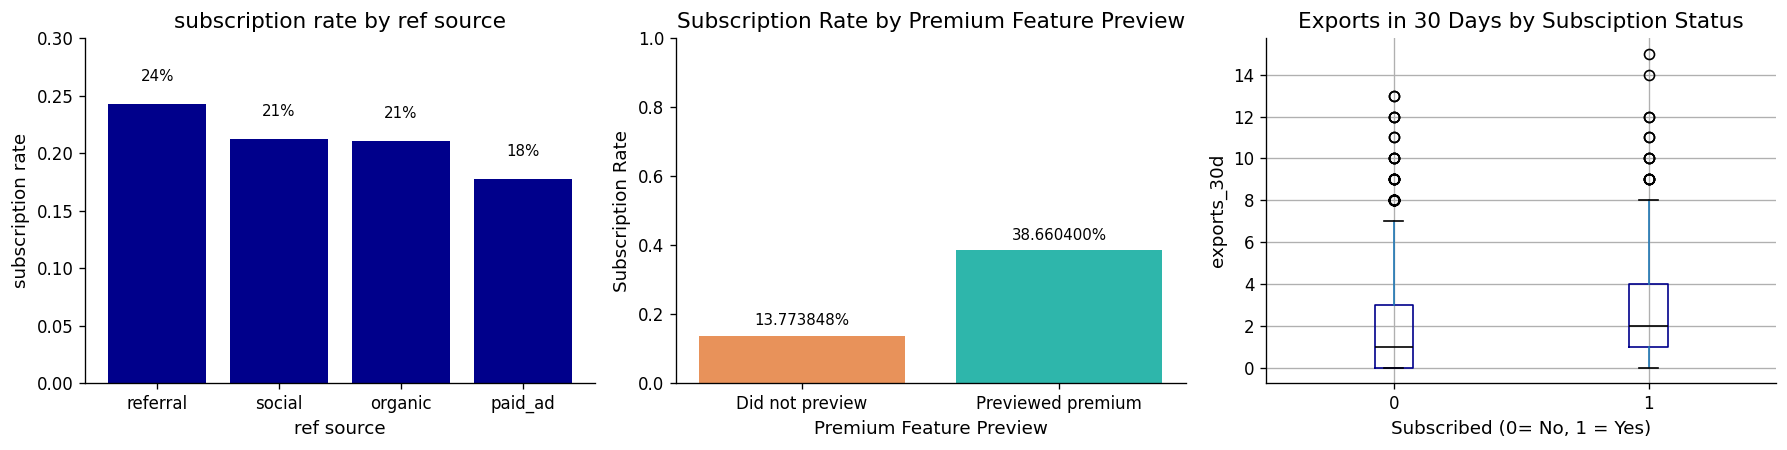

In [ ]:
# YOUR CODE HERE
# Visualize subscription rates across at least 3 features
# Suggestions:
#   - Bar chart: subscription rate by referral_source
#   - Bar chart: subscription rate by country_tier
#   - Boxplot: exports_30d distribution by subscribed (0 vs 1)
#   - Bar chart: subscription rate by used_premium_feature_preview
#   - Any other feature you find interesting

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Plot 1 — YOUR CODE
sub_by_ref = df_sub.groupby('referral_source')['subscribed'].mean().sort_values(ascending=False)
axes[0].bar(sub_by_ref.index, sub_by_ref.values, color="darkblue")
axes[0].set_title("subscription rate by ref source")
axes[0].set_xlabel("ref source")
axes[0].set_ylabel("subscription rate")
axes[0].set_ylim(0,0.3)

for i,v in enumerate(sub_by_ref.values):
  axes[0].text(i, v + 0.02, f'{v:.0%}', ha='center', fontsize=9)


# Plot 2 — YOUR CODE
sub_by_premium = df_sub.groupby('used_premium_feature_preview')['subscribed'].mean()
labels = ['Did not preview', 'Previewed premium']
axes[1].bar(labels, sub_by_premium.values, color = [ACCENT, '#2eb6ab'])
axes[1].set_title('Subscription Rate by Premium Feature Preview')
axes[1].set_xlabel('Premium Feature Preview')
axes[1].set_ylabel('Subscription Rate')
axes[1].set_ylim(0,1)
for i,v in enumerate(sub_by_premium.values):
  axes[1].text(i,v + 0.03, f'{v:0%}', ha='center', fontsize=9)


# Plot 3 — YOUR CODE
df_sub.boxplot(column='exports_30d', by='subscribed', ax=axes[2],
               boxprops=dict(color='darkblue'), medianprops=dict(color='black'))
axes[2].set_title('Exports in 30 Days by Subsciption Status')
axes[2].set_xlabel('Subscribed (0= No, 1 = Yes)')
axes[2].set_ylabel('exports_30d')
plt.suptitle('') #removing default boxplot title

plt.tight_layout()
plt.show()


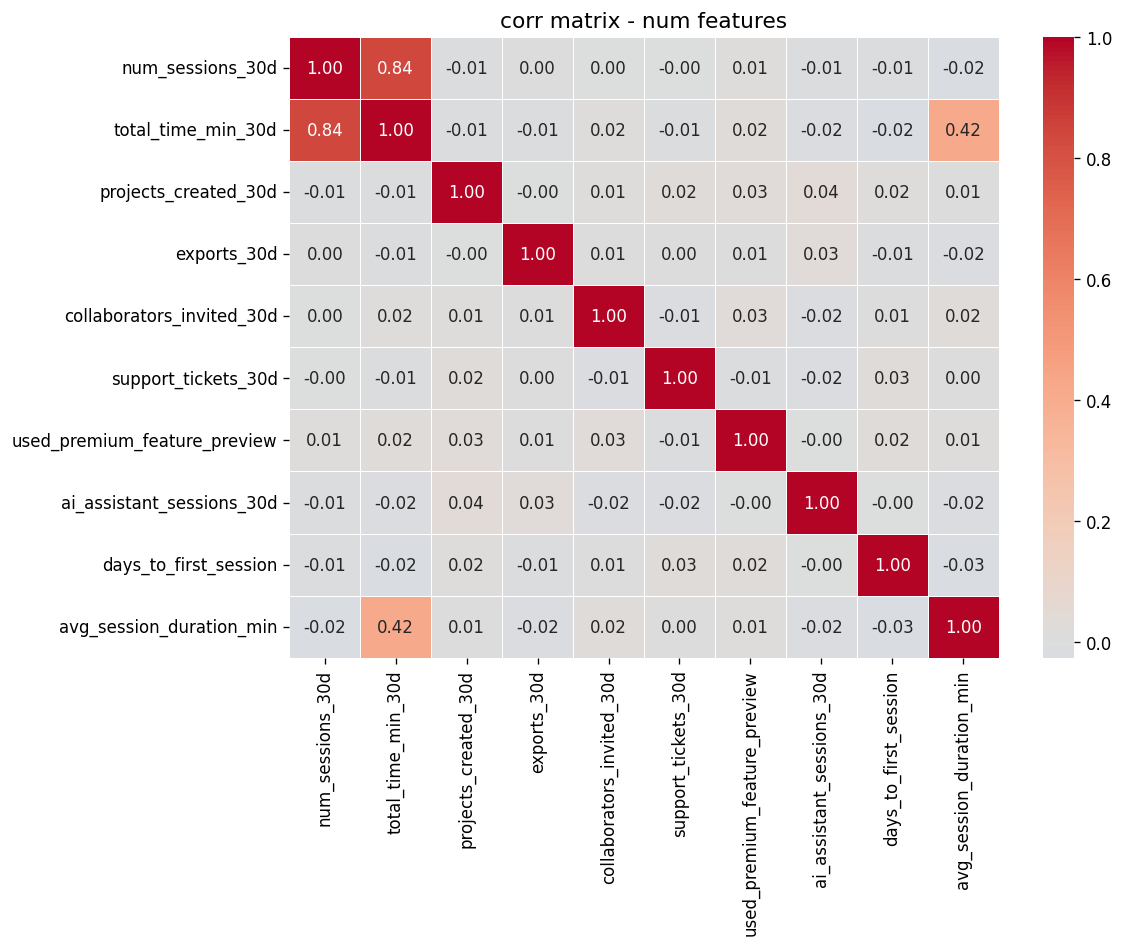

In [ ]:
# YOUR CODE HERE
# Correlation matrix of numeric features (exclude user_id and binary outcome)
# numeric_features = X_sub.select_dtypes(include='number').columns.tolist()
# corr = X_sub[numeric_features].corr()
# Plot as heatmap

numeric_features = [
    'num_sessions_30d', 'total_time_min_30d', 'projects_created_30d',
    'exports_30d', 'collaborators_invited_30d', 'support_tickets_30d',
    'used_premium_feature_preview', 'ai_assistant_sessions_30d',
    'days_to_first_session', 'avg_session_duration_min'
]

corr = X_sub[numeric_features].corr()

fig, ax = plt.subplots(figsize = (10,8))

sns.heatmap (
  corr,
  annot=True,
  fmt='.2f',
  cmap='coolwarm',
  center=0,
  ax=ax,
  linewidths=0.35
)

ax.set_title("corr matrix - num features")
plt.tight_layout()
plt.show()


**✏️ Your interpretation (B2):**

**Which two or three features appear most strongly associated with subscription in your EDA?** <br>
I would say used_premium_feature_preview is the most promising. The subscription rate almost triples from those who didnt preview (goes from 13.8% to 38.7%). Exports_30d alsop shows interesting results. Subscribers show a higher median and more higher outliers than those who did not subscribe. The source of referral also showed a smaller gap since

**Are any findings counterintuitive?** <br>
Support_tickets_30d shows basically no correalation to everything else which is kind of surprising. I wouldve expected support tickets to indicate how invested or annoyed a user is with the platform but it seems to be unrelated. I think the paid referrals also coverting the worst is counterintuitive since I'd assume paid ads would target the specific audiences and demographics invested in Phigma premium features

**Note any features that appear highly correlated with each other — does this concern you?**<br>
Total_time_min_30d and num_sessions_30d are 0.84 correlated which makes alot of sense since more sessions would end up meaning more time spent. I think it is concerning sice if both fo into the same logistic regression, they could become harder to interpret. I would consider dropping one or relying on avg_session_duration_min which is already a ratio of the two. The 0.42 correalation between avg_session_duration_min and total_time_min_30d is also moderately high but it is expected and not as concerning

### B3 — Logistic Regression with statsmodels (Inferential)

We fit on the **full dataset** here to maximize statistical power for inference.  
No train/test split — the goal is to interpret coefficients, not evaluate prediction.


In [ ]:
# YOUR CODE HERE
X_const_sub = sm.add_constant(X_sub.astype(float))
model_logit = sm.Logit(y_sub, X_const_sub).fit()
print(model_logit.summary())

Optimization terminated successfully.
         Current function value: 0.440520
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:             subscribed   No. Observations:                 3000
Model:                          Logit   Df Residuals:                     2982
Method:                           MLE   Df Model:                           17
Date:                Mon, 06 Jul 2026   Pseudo R-squ.:                  0.1392
Time:                        23:12:58   Log-Likelihood:                -1321.6
converged:                       True   LL-Null:                       -1535.2
Covariance Type:            nonrobust   LLR p-value:                 3.542e-80
                                   coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------
const                           -2.5253      0.325     -7.772      0.000

In [ ]:
# YOUR CODE HERE
# Compute odds ratios for all significant predictors (p < 0.05)
# Combine into a readable table and display
# Filter to significant only: p < 0.05

odds_ratios = np.exp(model_logit.params)
conf_int    = np.exp(model_logit.conf_int())

conf_int = np.exp(model_logit.conf_int())
conf_int.columns = ["OR_lower_95", "OR_upper_95"]

or_table = pd.DataFrame({
    'Odds Ratio': odds_ratios,
    'OR lower 95%': conf_int['OR_lower_95'],
    'OR upper 95%': conf_int['OR_upper_95'],
    'p-value': model_logit.pvalues
})

significants = or_table[
    (or_table['p-value'] < 0.05) & (or_table.index != 'const')
].sort_values('Odds Ratio', ascending=False)

print(significants.round(4).to_string())


                              Odds Ratio  OR lower 95%  OR upper 95%  p-value
used_premium_feature_preview      4.3470        3.5745        5.2864   0.0000
exports_30d                       1.2142        1.1633        1.2674   0.0000
support_tickets_30d               1.1673        1.0727        1.2702   0.0003
collaborators_invited_30d         1.0632        1.0178        1.1106   0.0059
avg_session_duration_min          1.0315        1.0112        1.0523   0.0023
days_to_first_session             0.9114        0.8872        0.9364   0.0000
country_tier_enc                  0.7001        0.6158        0.7959   0.0000


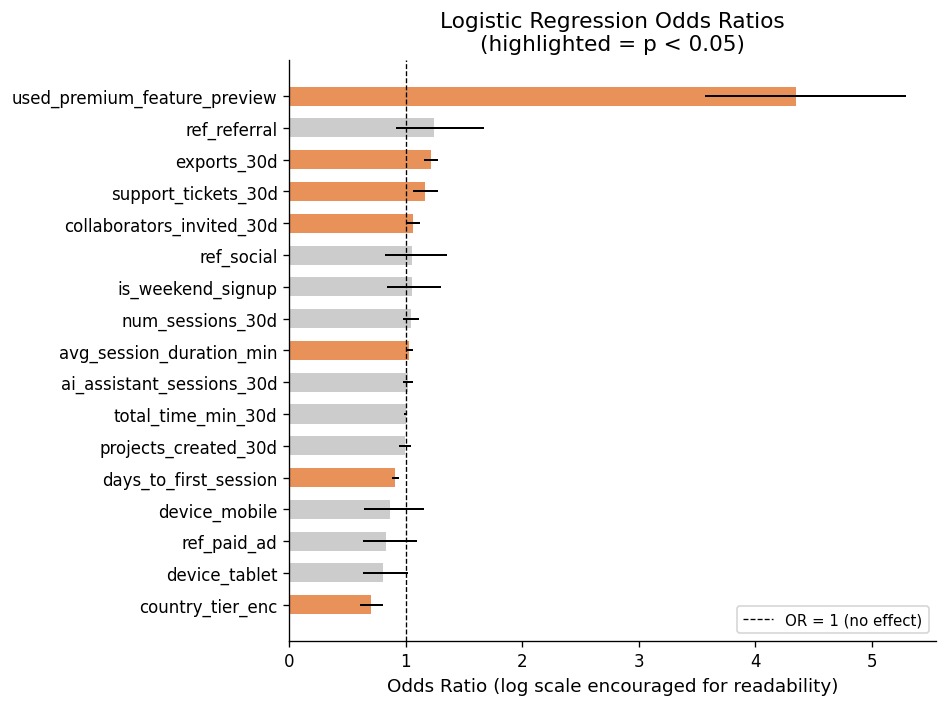

In [ ]:
# YOUR CODE HERE
# Visualize odds ratios as a horizontal bar chart (forest plot style)
# Show confidence intervals if possible
# Order bars by magnitude


or_all = pd.DataFrame({
    'Odds Ratio': np.exp(model_logit.params),
    'lower': np.exp(model_logit.conf_int()[0]),
    'upper': np.exp(model_logit.conf_int()[1]),
    'p-value': model_logit.pvalues
    }).drop('const').sort_values('Odds Ratio')


fig, ax = plt.subplots(figsize=(8, 6))

colors = [ACCENT if p < 0.05 else '#cccccc' for p in or_all['p-value']]


ax.barh(or_all.index, or_all['Odds Ratio'], color=colors, height=0.6)

for i, (idx, row) in enumerate(or_all.iterrows()):
  ax.plot([row['lower'], row['upper']], [i, i], color='black', lw=1.2)

ax.axvline(x=1, color='black', linestyle='--', lw=0.8, label='OR = 1 (no effect)')

ax.set_xlabel('Odds Ratio (log scale encouraged for readability)')
ax.set_title('Logistic Regression Odds Ratios\n(highlighted = p < 0.05)')
ax. legend(fontsize=9)
plt.tight_layout()
plt.show()

**✏️ Results paragraph (B3):**

**Interpret at least three odds ratios in plain English (e.g. "Users who previewed a premium feature were X times more likely to subscribe...").**<br>
*Days_to_first_session OR = 0.91* <br>
Each extra day it took a user to start their first session showed a 9% decrease in the odds of subscribing, which would mean that users who used the tool quickly after signing up were more likely to subscribe than those who took longer.<br>

*used_premium_feature_preview OR = 4.35* <br>
Users who previewed the premium feature were roughlu 4.3 times more likely to subscribe than those who did not<br>

*exports_30d OR=1.21* <br>
Each added export in the 30 day timeframe showed a 21% increase in how likely they are to subscribe (this also supports my earlier analysis/prediction in B1 for this feature)<br>

**Identify at least one predictor whose sign or magnitude surprised you and offer an explanation.**<br>
Again, support_tickets_30d showed a surprising result. It showed OR = 1.17 which meant that each additional support ticket showed a 17% increase in how likely they'd be to subscribe. This contradicts my original statement of support tickets indicating a user having issues or problems.

I think this could be explained by the action of submiting a support ticket showing heightened engagement with the platform. It shows that they are invested in the improvement and further usage of Phigma.

### B4 — Logistic Regression with sklearn (Predictive)


In [ ]:
# YOUR CODE HERE
# Train/test split — use these exact parameters so Part C comparisons are valid
X_train, X_test, y_train, y_test = train_test_split(
    X_sub, y_sub, test_size=0.2, random_state=42, stratify=y_sub
)
print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")
print(f"Train positive rate: {y_train.mean():.3f}  |  Test positive rate: {y_test.mean():.3f}")


Train: (2400, 17)  |  Test: (600, 17)
Train positive rate: 0.208  |  Test positive rate: 0.208


In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

clf_lr = LogisticRegression(max_iter=1000, random_state=42)
clf_lr.fit(X_train_scaled, y_train)

y_pred_lr = clf_lr.predict(X_test_scaled)
y_prob_lr = clf_lr.predict_proba(X_test_scaled)[:, 1]

print(f"{X_train_scaled.shape[0]}")
print(f"{X_test_scaled.shape[0]}")

2400
600


In [ ]:
# YOUR CODE HERE
# Fit sklearn LogisticRegression

clf_lr = LogisticRegression(max_iter=1000, random_state=42)
clf_lr.fit(X_train, y_train)
y_pred_lr = clf_lr.predict(X_test)
y_prob_lr = clf_lr.predict_proba(X_test)[:, 1]


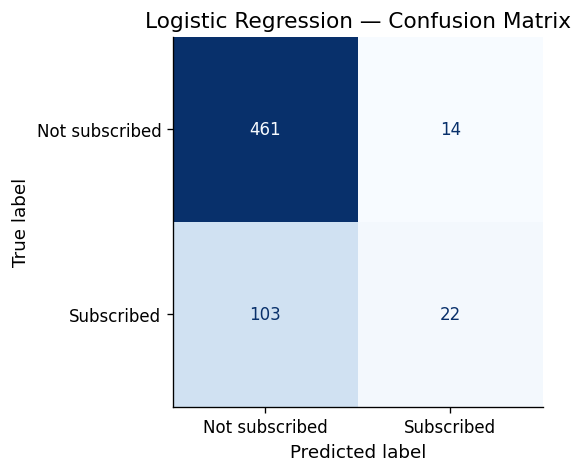

True negative: 461
False positive: 14
False negative: 103
True positive: 22
accuracy : 0.805
recall : 0.176
percision : 0.6111111111111112


In [ ]:
# YOUR CODE HERE
# Confusion matrix heatmap
cm_lr = confusion_matrix(y_test, y_pred_lr)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=['Not subscribed', 'Subscribed'])
fig, ax = plt.subplots(figsize=(5, 4))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
plt.title('Logistic Regression — Confusion Matrix')
plt.show()

tn, fp, fn, tp = cm_lr.ravel()

print(f"True negative: {tn}")
print(f"False positive: {fp}")
print(f"False negative: {fn}")
print(f"True positive: {tp}")

acc = (tn + tp) / 600
print(f"accuracy : {acc}")

rec = tp / (tp + fn)
print(f"recall : {rec}")

prec = tp / (tp + fp)
print(f"percision : {prec}")


In [ ]:
# YOUR CODE HERE
# Classification report
print(classification_report(y_test, y_pred_lr, target_names=['Not subscribed', 'Subscribed']))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_lr):.4f}")


                precision    recall  f1-score   support

Not subscribed       0.82      0.97      0.89       475
    Subscribed       0.61      0.18      0.27       125

      accuracy                           0.81       600
     macro avg       0.71      0.57      0.58       600
  weighted avg       0.77      0.81      0.76       600

ROC-AUC: 0.7375


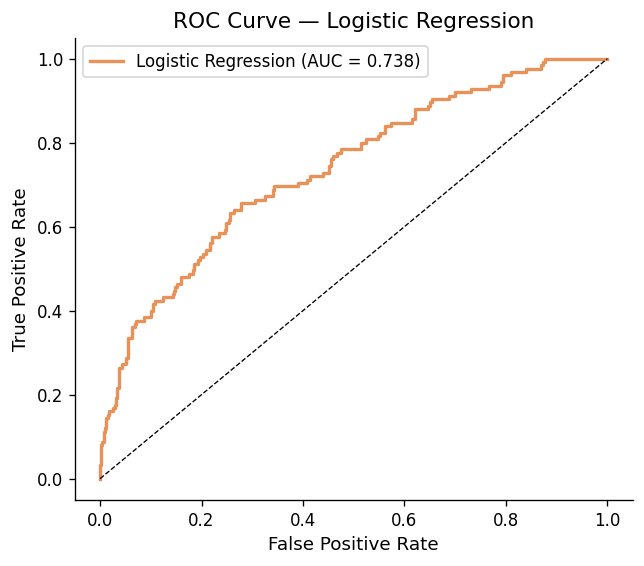

In [ ]:
# YOUR CODE HERE
# ROC curve (save fpr_lr, tpr_lr for later comparison with Part C)
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
auc_lr = roc_auc_score(y_test, y_prob_lr)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr_lr, tpr_lr, color=ACCENT, lw=2, label=f'Logistic Regression (AUC = {auc_lr:.3f})')
ax.plot([0,1],[0,1], 'k--', lw=0.8)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve — Logistic Regression')
ax.legend()
plt.show()


**✏️ Your interpretation (B4):**

**Which metric did you decide is most important given the class imbalance, and why?**<br>
The results show only 20.8% of users subscribing, which shows that accuracy could be misleading (since predicting no for everyone would still mean that it it 79% accurate). So instead what I think matters the most is recall, so how many actual/real subscribers the model catches.

**Interpret the confusion matrix: how many false negatives does the model produce?**<br>
The model showed 103 false nagatives meaning 103 real subscibers it predicted would not subscribe. Out of the actual 125 real subscribers it only cause 22 so most of them were missed.

**From Phigma's business perspective, what is the cost of a false negative (a user who would have subscribed but the model missed)?**<br>
A false negative means that the model missed someone who was actually going to subscribe. This would mean that the platform misses out on triggering offers to people who would actually pay for the service. This is to the detriment of the company and how successful Phigma becomes. Missing 103 out of 125 real subscribers would cost the company alot of engaged viewers and profit.

---

## Part C — Your Model: Choose, Learn, Apply, Compare

**Dataset:** `phigma_subscription.csv`  
**Same train/test split as B4.** Do not re-split.


### C1 — Choose Your Model

Available options: Decision Tree, Random Forest, Gradient Boosting, XGBoost, LightGBM, K-Nearest Neighbors, Naive Bayes, SVM, LDA, AdaBoost.


**✏️ Your chosen model:** `Decision Tree`

**Conceptual explanation (write this before any code):**

**How does this model learn from training data?** <br>
It splits the data into groups multple times over while picking the feature and limit that best separates the subscribers from the non subs. It keeps on splitting until it hits a stopping point, ending with an "if this, then that" rules

**What does it optimize?** <br>
At every split it picks whatever divides the subs and non subs most cleanly, it makes the best local choice at each split

**How is it structurally different from logistic regression?** <br>
Logistic regression uses a linear straight line relationshop between each feature and chance of subscribing. A decision try chunks the data through yes or no splits so it can pick ip on non linear patterns without needing them known in advance.

**Why might it perform differently on this particular dataset given what you know about the features?**<br>
Used_premium_feature_preview behaves more like a yes or no, rather than a linear smooth trend, a tree would be able to capture this in a clean split. Also it also would not get confused between the num_sessions_30d and total_time_min_30d results. once it splits in on one the other contributes little extra (this was noted as an issue with logistic regression above)

### C2 — Fit and Evaluate


In [ ]:
# YOUR CODE HERE
# Import your chosen model, e.g.:
# from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
# from sklearn.neighbors import KNeighborsClassifier
# from sklearn.naive_bayes import GaussianNB
# from sklearn.svm import SVC
# from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
# from sklearn.ensemble import GradientBoostingClassifier, AdaBoostClassifier
# from xgboost import XGBClassifier  # pip install xgboost
# from lightgbm import LGBMClassifier  # pip install lightgbm

# Fit with default hyperparameters
clf_c = DecisionTreeClassifier(random_state=42)   # add random_state if supported
clf_c.fit(X_train, y_train)
y_pred_c = clf_c.predict(X_test)
y_prob_c = clf_c.predict_proba(X_test)[:, 1]
# omit if model has no predict_proba (e.g. SVM)


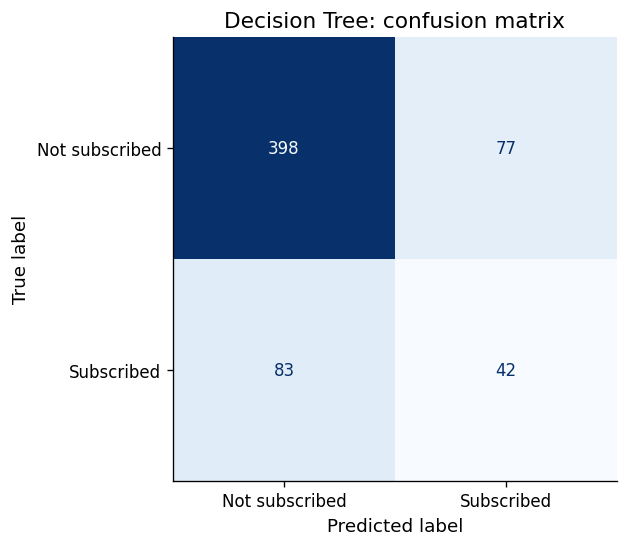

true negative: 398
false positive: 77
false negative: 83
true positive: 42


In [ ]:
# YOUR CODE HERE
# Confusion matrix

cm = confusion_matrix(y_test, y_pred_c)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not subscribed', 'Subscribed'])
disp.plot(cmap='Blues', values_format='d', colorbar = False)
plt.title('Decision Tree: confusion matrix')
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"true negative: {tn}")
print(f"false positive: {fp}")
print(f"false negative: {fn}")
print(f"true positive: {tp}")


In [ ]:
# YOUR CODE HERE
# Classification report + ROC-AUC

print(classification_report(y_test, y_pred_c, target_names=['Not subscribed', 'Subscribed']))

auc_c = roc_auc_score(y_test, y_prob_c)
print(f"roc-auc: {auc_c:.4f}")


                precision    recall  f1-score   support

Not subscribed       0.83      0.84      0.83       475
    Subscribed       0.35      0.34      0.34       125

      accuracy                           0.73       600
     macro avg       0.59      0.59      0.59       600
  weighted avg       0.73      0.73      0.73       600

roc-auc: 0.5869


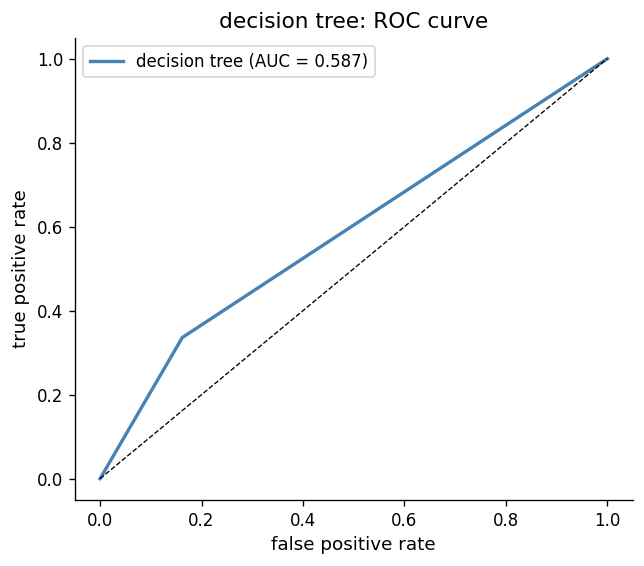

In [ ]:
# YOUR CODE HERE
# ROC curve (save fpr_c, tpr_c, auc_c for comparison plot)

fpr_c, tpr_c, _ = roc_curve(y_test, y_prob_c)
auc_c = roc_auc_score(y_test, y_prob_c)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr_c, tpr_c, color='steelblue', lw=2, label=f'decision tree (AUC = {auc_c:.3f})')
ax.plot([0,1],[0,1], 'k--', lw=0.8)
ax.set_xlabel('false positive rate')
ax.set_ylabel('true positive rate')
ax.set_title('decision tree: ROC curve')
ax.legend()
plt.show()

### C3 — Model Comparison


In [ ]:
# YOUR CODE HERE
# Summary comparison table
# metrics = {
#     'Model': ['Logistic Regression', 'YOUR MODEL NAME'],
#     'ROC-AUC': [...],
#     'F1 (class 1)': [...],
#     'Precision (class 1)': [...],
#     'Recall (class 1)': [...],
# }
# pd.DataFrame(metrics).set_index('Model').round(4)

from sklearn.metrics import precision_score, recall_score, f1_score

metrics = {
    'Model': ['Logistic Regression', 'Decision Tree'],
    'ROC-AUC': [auc_lr, auc_c],
    'F1 (class 1)': [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_c)
    ],
    'Precision (class 1)': [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_c)
    ],
    'Recall (class 1)': [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_c)
    ],
}

pd.DataFrame(metrics).set_index('Model').round(4)


,ROC-AUC,F1 (class 1),Precision (class 1),Recall (class 1)
Model,,,,
Logistic Regression,0.7375,0.2733,0.6111,0.176
Decision Tree,0.5869,0.3443,0.3529,0.336


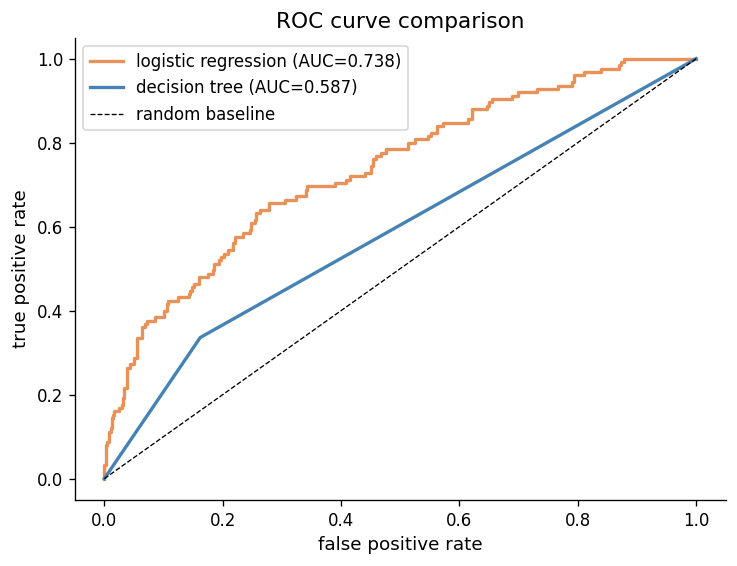

In [ ]:
# YOUR CODE HERE
# Dual ROC curve plot
fig, ax = plt.subplots(figsize=(7, 5))

ax.plot(fpr_lr, tpr_lr, color=ACCENT, lw=2, label=f'logistic regression (AUC={auc_lr:.3f})')
ax.plot(fpr_c, tpr_c, color='steelblue', lw=2, label=f'decision tree (AUC={auc_c:.3f})')
ax.plot([0,1], [0,1], 'k--', lw=0.8, label='random baseline')

ax.set_xlabel('false positive rate')
ax.set_ylabel('true positive rate')
ax.set_title('ROC curve comparison')
ax.legend()
plt.show()

**✏️ Comparison paragraph (C3):**

**Which model performs better, and by how much?** <br>

Logistic regression definitely performs better when it comes to ROC-AUC (0.738 vs 0.587). It also performs much better for percision (0.61 vs. 0.35).

Although, the decision tree performs better when it comes to recall (0.336 vs 0.176). It also has a better F1 score (0.344 vs 0.273).

When looking at the ROC curve, the decision tree has a very rigid angled shape thats barely above the baseline. This hsows that it's the weaker model when comparing the two, so logistic regression is the better performing model.

**Explain *why* the performance difference occurred — based on what you know about how each model works and the structure of this dataset (non-linearities, class imbalance, number of features).** <br>
With the default hyperparamaters, a single decision tree overfits on training data. This could explain why ROC-AUC is so much weaker.

It could also be that there are not enough features to work off of for the model. There are 17 features which may not be enough complexity for the tree to use.

The class imbalance could also be affecting the trees more. Since there are only 21% of subs, the tree could end up making decisions based on a few less significant class examples on certain branches. This could be causing unstable splits for the subscribed class. Since logistic regression estimates probability accross the hole dataset it may be handling this better.

**If your model performed worse than logistic regression, that is a valid finding — explain why.** <br>
I think it still is a valid finding, it shows that a more flexible model isnt better by default. In the dataset, the relationshops seem simple enough that a logistic regression model would generalize better than a decision tree model which could be prone to overfitting.

### C4 — Bonus: Hyperparameter Tuning (+5 points)

*Complete this section only if you want to attempt the bonus.*


In [ ]:
# YOUR CODE HERE (BONUS)
# from sklearn.model_selection import GridSearchCV  # or RandomizedSearchCV

# Define a parameter grid relevant to your chosen model
# param_grid = { ... }

# Run cross-validated search on the TRAINING SET ONLY
# search = GridSearchCV(YourModel(), param_grid, cv=5, scoring='roc_auc', n_jobs=-1)
# search.fit(X_train, y_train)

# print(f"Best parameters: {search.best_params_}")
# print(f"Best CV AUC:     {search.best_score_:.4f}")

# Evaluate tuned model on test set
# y_pred_tuned = search.best_estimator_.predict(X_test)
# y_prob_tuned = search.best_estimator_.predict_proba(X_test)[:, 1]
# print(f"Tuned test AUC:  {roc_auc_score(y_test, y_prob_tuned):.4f}")
# print(f"Default test AUC:{auc_c:.4f}")
# print("Did tuning meaningfully improve results? [Your one sentence here]")


---

## Submission Checklist

Before submitting, confirm:

- [ ] All `# YOUR CODE HERE` cells are completed and run without errors
- [ ] All `**✏️ Your interpretation**` cells contain your own written analysis
- [ ] The notebook runs top-to-bottom without errors (`Kernel > Restart & Run All`)
- [ ] File is named `iat461_a2_[YourName]_[SFUid].ipynb`
- [ ] PDF export is named `iat461_a2_[YourName]_[SFUid].pdf`
- [ ] All AI-assisted code blocks include `#BEGIN` / `#END` disclosure comments
